In [90]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
import os
import shutil
from kagglehub import KaggleDatasetAdapter
import warnings
warnings.filterwarnings("ignore")

# Set the path to the file you'd like to load
file_path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")

print(f"Dataset downloaded to - {file_path}")

destination_folder = r"D:\airbnbda"


# create the destination folder if it doesnt exist
os.makedirs(destination_folder, exist_ok=True)

# moving the item 
for item in os.listdir(file_path):
    s = os.path.join(file_path, item)
    d = os.path.join(destination_folder, item)
    if os.path.isdir(s):
        shutil.copytree(s, d,  dirs_exist_ok=True)
    else:
        shutil.copy2(s,d)

print(f"Dataset moved to : {destination_folder}")

Dataset downloaded to - C:\Users\user\.cache\kagglehub\datasets\dgomonov\new-york-city-airbnb-open-data\versions\3
Dataset moved to : D:\airbnbda


In [63]:
import numpy as np
import pandas as pd


df = pd.read_csv('AB_NYC_2019.csv')


df.head()


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [66]:
# filling the missing values 
df['name'] = df['name'].fillna('Unknown')
df['host_name'] = df['host_name'].fillna('Unknown')
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

In [67]:
df.isnull().sum()

id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [68]:
list(df.columns)

['id',
 'name',
 'host_id',
 'host_name',
 'neighbourhood_group',
 'neighbourhood',
 'latitude',
 'longitude',
 'room_type',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'last_review',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365']

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48895 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48895 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

#### Starting with exploratory data analysis

In [70]:
print(f"There are {df['neighbourhood'].nunique()} different neighborhoods.")

There are 221 different neighborhoods.


In [71]:
# counting the number of properties per neighborhoods
df['neighbourhood'].value_counts()

neighbourhood
Williamsburg          3920
Bedford-Stuyvesant    3714
Harlem                2658
Bushwick              2465
Upper West Side       1971
                      ... 
Richmondtown             1
Fort Wadsworth           1
New Dorp                 1
Rossville                1
Willowbrook              1
Name: count, Length: 221, dtype: int64

In [72]:
print(f"There are {df['neighbourhood_group'].nunique()} unique neighborhood groups.")

There are 5 unique neighborhood groups.


In [73]:
df['neighbourhood_group'].value_counts()

neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64

In [74]:
df.groupby(['neighbourhood_group', 'neighbourhood']).agg(
    counts = ('id', 'count')
).sort_values(by=['counts'], ascending=False).reset_index()

,neighbourhood_group,neighbourhood,counts
0,Brooklyn,Williamsburg,3920
1,Brooklyn,Bedford-Stuyvesant,3714
2,Manhattan,Harlem,2658
3,Brooklyn,Bushwick,2465
4,Manhattan,Upper West Side,1971
...,...,...,...
216,Staten Island,New Dorp,1
217,Staten Island,Richmondtown,1
218,Staten Island,Rossville,1
219,Staten Island,Willowbrook,1


the dense population of the airbnb's are in Brooklyn and Manhattan

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

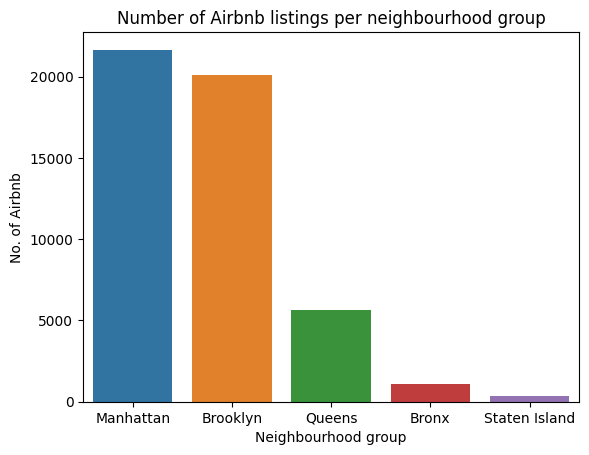

In [76]:
sns.barplot(data=df.groupby('neighbourhood_group')\
            .agg(counts=('id', 'count'))\
                .sort_values(by='counts', ascending=False),
             x = 'neighbourhood_group', y='counts', hue='neighbourhood_group')


plt.xlabel('Neighbourhood group')
plt.ylabel('No. of Airbnb')
plt.title('Number of Airbnb listings per neighbourhood group')
plt.show();

##### Manhattan and Brooklyn have the most number of property listings

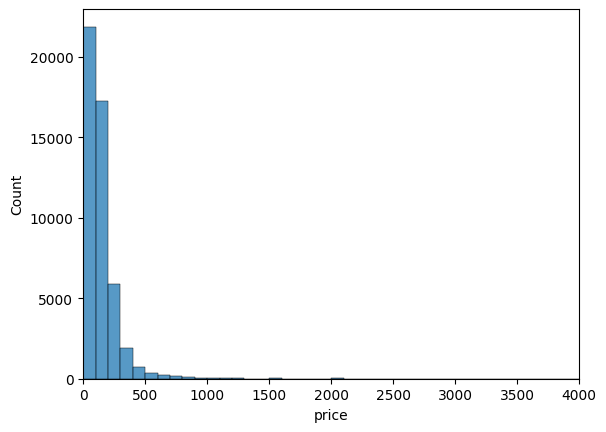

In [77]:
# creating a histplot of the price

sns.histplot(data=df, x='price', bins=100)

plt.xlim(0, 4000)
plt.show();

The price column is positively skewed

In [78]:
df.sample(10)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
39175,30557920,Great studio with beautiful backyard,148508902,Olga,Brooklyn,Sheepshead Bay,40.58640,-73.94320,Entire home/apt,69,1,42,2019-06-30,6.09,1,57
4218,2757036,Bayview room,14103991,Ruth,Queens,Flushing,40.75606,-73.81954,Private room,55,1,51,2019-05-26,0.82,4,333
21740,17477888,Cozy Private Room in Vibrant Williamsburg Apt,2861103,Sarah,Brooklyn,Williamsburg,40.71992,-73.94130,Private room,100,1,82,2019-05-05,2.95,1,0
2410,1186569,beautiful spacious room,6471461,Robert,Queens,Ridgewood,40.70823,-73.89925,Private room,55,1,224,2019-07-02,3.87,2,356
13481,10096773,Easy 1 Bedroom in Chelsea,34607505,Scott,Manhattan,Chelsea,40.74577,-74.00074,Entire home/apt,145,2,1,2016-01-03,0.02,1,0
43190,33499489,Room In Manhattan Close to Everything,251430918,Medena,Manhattan,Hell's Kitchen,40.76808,-73.98625,Private room,89,2,11,2019-07-01,3.51,2,54
5040,3624387,"Beautiful Apt x Rent in Astoria, NY",4666670,Jeanny,Queens,Long Island City,40.76481,-73.93163,Entire home/apt,120,6,25,2019-05-21,0.42,4,346
38762,30393194,Stately Central West Village 1BR w/ Gym + Door...,107434423,Blueground,Manhattan,West Village,40.72873,-74.00340,Entire home/apt,459,30,0,NaN,0.00,232,293
44207,34110599,The Green Place I,101790764,Zabi,Queens,Long Island City,40.74764,-73.94820,Entire home/apt,199,2,7,2019-06-22,3.28,2,170
23168,18753645,Beautiful Brooklyn Apartment! Newly Renovated!,130473272,Carla,Brooklyn,Prospect Heights,40.68060,-73.97164,Entire home/apt,150,2,140,2019-06-27,5.61,1,94


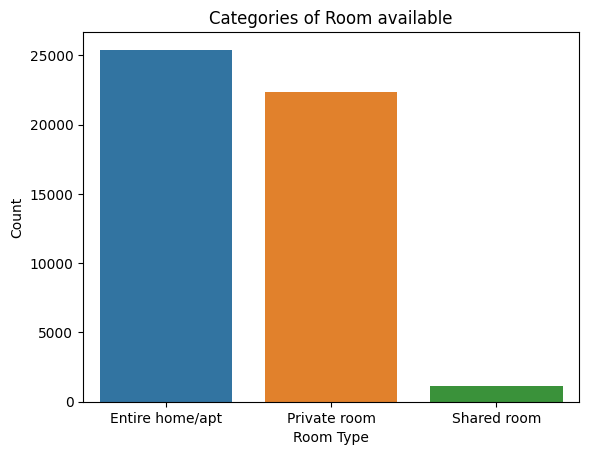

In [79]:
sns.barplot(data=df.groupby('room_type').agg(counts=('id', 'count')),
             x = 'room_type', y='counts', hue='room_type')


plt.xlabel("Room Type")
plt.ylabel("Count")

plt.title("Categories of Room available")

plt.show();

In [81]:
df['reviews_per_month'].describe()

count    48895.000000
mean         1.090910
std          1.597283
min          0.000000
25%          0.040000
50%          0.370000
75%          1.580000
max         58.500000
Name: reviews_per_month, dtype: float64

In [91]:
df['property_category'] = pd.qcut(df['reviews_per_month'], q=3, labels=['Low Rented', 'Medium Rented', 'High Rented'])

In [92]:
df['property_category'].value_counts()

property_category
Low Rented       16595
Medium Rented    16392
High Rented      15908
Name: count, dtype: int64

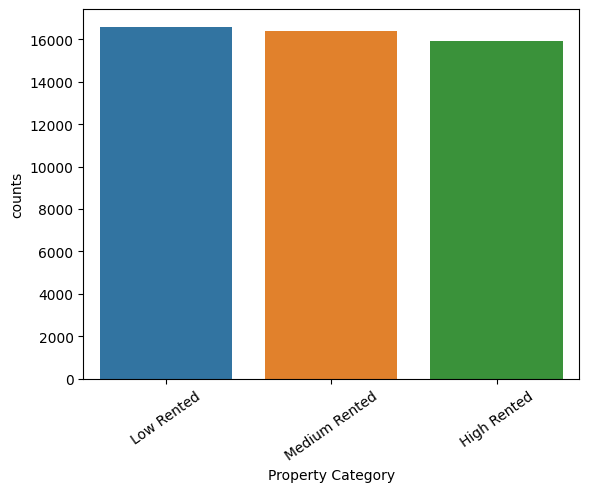

In [93]:
sns.barplot(data=df.groupby('property_category')\
            .agg(counts=('id', 'count'))\
            .sort_values(by='counts', ascending=False)
            ,x='property_category', y='counts', hue='property_category')

plt.xlabel('Property Category')

plt.xticks(rotation=35)
plt.show();

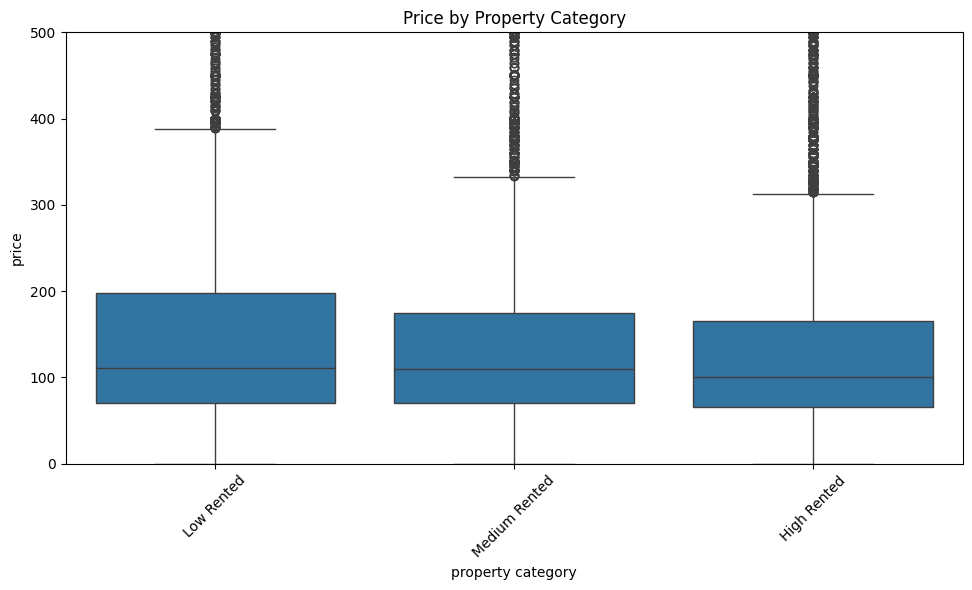

In [99]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='property_category', y='price', data=df)
plt.title("Price by Property Category")
plt.xlabel("property category")
plt.ylabel("price")
plt.xticks(rotation=45)
plt.tight_layout()

plt.ylim(0, 500)
plt.show();

In [116]:
plot_data = df.groupby('property_category').agg(
    avg_price=('price', 'mean'),
    price_range=('price', lambda x: x.max()-x.min())
).round(2).reset_index()

print(plot_data)

  property_category  avg_price  price_range
0        Low Rented     172.64        10000
1     Medium Rented     148.63        10000
2       High Rented     136.15         7500


The Low rented property have more price compared to the High rented and the medium rented properties.

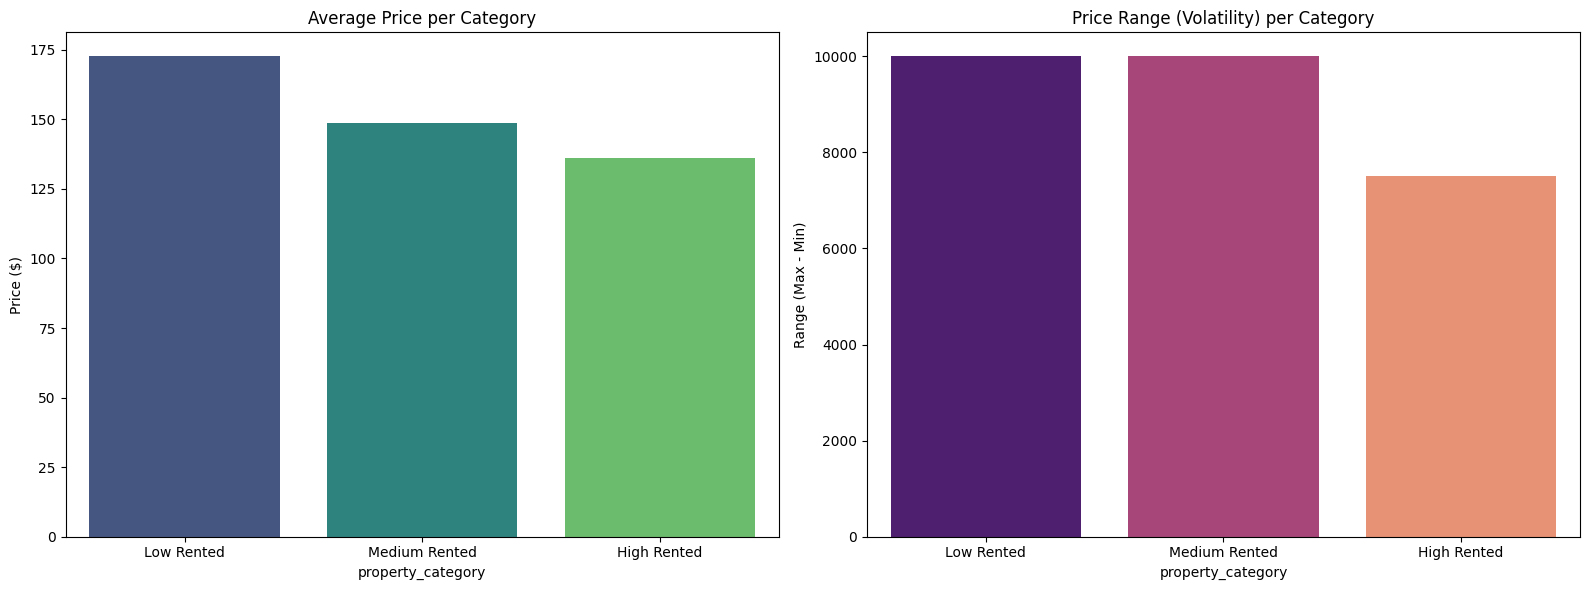

In [117]:
# Create a figure with 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Average Price (The Central Tendency)
sns.barplot(data=plot_data, x='property_category', y='avg_price', ax=ax1, palette='viridis')
ax1.set_title('Average Price per Category')
ax1.set_ylabel('Price ($)')

# Plot 2: Price Range (The Spread/Variance)
sns.barplot(data=plot_data, x='property_category', y='price_range', ax=ax2, palette='magma')
ax2.set_title('Price Range (Volatility) per Category')
ax2.set_ylabel('Range (Max - Min)')

plt.tight_layout() # Ensures labels don't overlap
plt.show()

In [94]:
df.sample(10)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,Property_category,property_category
4218,2757036,Bayview room,14103991,Ruth,Queens,Flushing,40.75606,-73.81954,Private room,55,1,51,2019-05-26,0.82,4,333,Medium Rented,Medium Rented
42987,33376169,BedStuy Private Room (D6),6206040,Linda,Brooklyn,Bedford-Stuyvesant,40.69050,-73.93038,Private room,49,2,6,2019-06-28,2.17,8,226,High Rented,High Rented
24247,19531901,"2BR near Central Park, Lincoln Center",7936109,Ryan,Manhattan,Upper West Side,40.77468,-73.98184,Entire home/apt,180,2,5,2017-08-12,0.20,1,0,Medium Rented,Medium Rented
38005,30037000,Calm apartment in Brooklyn,3297399,Adero,Brooklyn,East Flatbush,40.64391,-73.94833,Entire home/apt,57,1,6,2019-01-08,0.80,1,0,Medium Rented,Medium Rented
19627,15717652,Williamsburg Gem: Sleep up to 5,101529107,Natalie,Brooklyn,Williamsburg,40.71124,-73.96451,Entire home/apt,164,2,1,2017-01-04,0.03,1,0,Low Rented,Low Rented
45203,34598639,Comfy and Classic Brooklyn Brownstone 1 Bedroom!,1354539,Eve,Brooklyn,Bedford-Stuyvesant,40.68541,-73.95298,Entire home/apt,125,3,4,2019-06-18,4.00,1,155,High Rented,High Rented
13288,10000943,1 Bedroom in UWS Manhattan,6891770,Mido,Manhattan,Upper West Side,40.78239,-73.97581,Entire home/apt,199,2,10,2017-04-18,0.25,1,0,Medium Rented,Medium Rented
14148,10874577,Unbelievable luxury apartment,43220844,Adil,Manhattan,Upper East Side,40.76309,-73.95794,Entire home/apt,175,1,1,2016-02-16,0.02,1,0,Low Rented,Low Rented
27266,21540314,Clean & quiet home on quiet block,156585195,Gerard,Brooklyn,Bergen Beach,40.62052,-73.91145,Entire home/apt,95,2,41,2018-08-27,2.04,2,4,High Rented,High Rented
16187,13064913,Sunny Studio in the Heart of Downtown Brooklyn.,3872251,Santron,Brooklyn,Fort Greene,40.68589,-73.97659,Entire home/apt,100,2,13,2016-08-30,0.35,1,0,Medium Rented,Medium Rented


In [95]:
df.groupby(['neighbourhood_group', 'room_type'])\
    .agg(avg_price=('price', 'mean'))\
    .round(2)\
    .sort_values(by=['neighbourhood_group', 'avg_price'], ascending=[True, False])\
    .reset_index()

,neighbourhood_group,room_type,avg_price
0,Bronx,Entire home/apt,127.51
1,Bronx,Private room,66.79
2,Bronx,Shared room,59.80
3,Brooklyn,Entire home/apt,178.33
4,Brooklyn,Private room,76.50
5,Brooklyn,Shared room,50.53
6,Manhattan,Entire home/apt,249.24
7,Manhattan,Private room,116.78
8,Manhattan,Shared room,88.98
9,Queens,Entire home/apt,147.05


In [96]:
df.sample(5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,Property_category,property_category
32386,25348369,Aug 1st Park Slope roommate wanted-3 mos.,702103,Sherry,Brooklyn,South Slope,40.66736,-73.98546,Private room,48,60,0,NaN,0.00,1,342,Low Rented,Low Rented
15449,12385794,"CLEAN,SPACIOUS,CONVENIENT,FiDi/NYC Apartment",7511223,Shan,Manhattan,Financial District,40.70799,-74.00977,Entire home/apt,300,3,100,2019-06-22,2.66,1,335,High Rented,High Rented
12937,9838145,Bright 3 BR East Village apartment,5904463,Katherine,Manhattan,East Village,40.72451,-73.98369,Entire home/apt,250,1,0,NaN,0.00,4,0,Low Rented,Low Rented
17525,13781978,Beautiful Room in Modern Duplex,71857900,Jacqueline,Queens,Astoria,40.77153,-73.93191,Private room,150,2,0,NaN,0.00,1,0,Low Rented,Low Rented
1753,793951,Beautiful Bedroom in Harlem,4182834,Cruz,Manhattan,Harlem,40.82169,-73.93882,Private room,78,1,52,2017-08-14,0.66,1,0,Medium Rented,Medium Rented


In [29]:
# finding the most popular host

df.groupby('host_name').agg(
    no_of_property_visits = ('id', 'count')
)\
.sort_values(by='no_of_property_visits', ascending=False)\
.reset_index()

,host_name,no_of_property_visits
0,Michael,417
1,David,403
2,Sonder (NYC),327
3,John,294
4,Alex,279
...,...,...
11448,(Ari) HENRY LEE,1
11449,'Cil,1
11450,현선,1
11451,A-B,1


This is a bit misleading since there a lot of Micheal's in the host name column. 

In [30]:
df.loc[df['host_name']=='Michael']

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,property_category
151,36121,Lg Rm in Historic Prospect Heights,62165,Michael,Brooklyn,Prospect Heights,40.67386,-73.96641,Private room,85,15,9,2013-05-10,0.09,1,339,Least Rented property
412,138216,Sunny and Spacious Designer's Home,674970,Michael,Brooklyn,Greenpoint,40.72212,-73.94254,Entire home/apt,141,5,8,2018-07-08,0.21,1,9,Least Rented property
519,189135,Hell's Kitchen Funky 80's Hideaway!,179020,Michael,Manhattan,Hell's Kitchen,40.76311,-73.99388,Private room,99,1,89,2019-07-01,1.00,1,353,Least Rented property
616,233189,NYC Studio in Heart of Times Square,1220414,Michael,Manhattan,Hell's Kitchen,40.76166,-73.99675,Entire home/apt,179,30,83,2019-05-31,0.88,1,292,Least Rented property
811,289037,"2BR in Cobble Hill, Brooklyn, NY",632334,Michael,Brooklyn,Carroll Gardens,40.68353,-73.99140,Entire home/apt,189,2,13,2016-09-05,0.18,1,0,Least Rented property
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48378,36228909,Sunny SoHo Penthouse w/ Pvt. Terrace!,272485928,Michael,Manhattan,SoHo,40.72336,-74.00465,Entire home/apt,600,3,0,NaN,0.00,1,179,Least Rented property
48531,36310247,Spacious 1 Bedroom With Private Garden,25498509,Michael,Brooklyn,Clinton Hill,40.68183,-73.96464,Entire home/apt,100,1,0,NaN,0.00,1,6,Least Rented property
48786,36426788,Serene Room 5 mins from JFK / 15 mins from LGA,266645207,Michael,Queens,Laurelton,40.67025,-73.74548,Private room,75,1,0,NaN,0.00,2,180,Least Rented property
48830,36450318,"LUXURY, PRIVATE APT ACROSS FROM EMPIRE STATE",151831356,Michael,Manhattan,Midtown,40.74607,-73.98599,Entire home/apt,199,1,0,NaN,0.00,1,14,Least Rented property


In [31]:
df['name'].nunique()

47906

we have to check in terms of the property name and how often they are visited

In [32]:
df.groupby('name').agg(
    total_visits = ('id', 'count')
).sort_values(by='total_visits', ascending=False)

,total_visits
name,
Hillside Hotel,18
Home away from home,17
Unknown,16
New york Multi-unit building,16
Brooklyn Apartment,12
...,...
한성 韓城 Han B (2F),1
한성 韓城 Han C (2F),1
️CENTRALLY LOCATED️- Great for Families + Groups,1


In [33]:
df.loc[df['name']=='Home away from home']

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,property_category
16309,13125243,Home away from home,46087238,Michion,Queens,Jamaica,40.68723,-73.78791,Private room,40,1,14,2018-10-11,0.42,2,335,Least Rented property
16522,13238321,Home away from home,40976536,Jeff,Manhattan,Harlem,40.82963,-73.94950,Private room,69,1,34,2019-07-05,0.91,1,180,Least Rented property
24723,19856899,Home away from home,67739226,Vipul,Manhattan,Upper West Side,40.77141,-73.98862,Shared room,50,1,0,NaN,0.00,1,0,Least Rented property
25100,20111316,Home away from home,15758568,Mike,Brooklyn,Bedford-Stuyvesant,40.68121,-73.94471,Private room,50,2,17,2019-06-24,0.76,1,89,Least Rented property
29362,22517063,Home away from home,122283834,Eve,Queens,Cambria Heights,40.69807,-73.74432,Private room,50,5,0,NaN,0.00,2,96,Least Rented property
30933,23963981,Home away from home,180208872,Ketia,Brooklyn,Canarsie,40.63382,-73.90502,Entire home/apt,155,1,82,2019-07-05,6.97,1,302,Least Rented property
33618,26604019,Home away from home,40398107,Joey,Brooklyn,Midwood,40.61615,-73.95997,Entire home/apt,70,1,1,2018-07-17,0.08,1,0,Least Rented property
35636,28291780,Home away from home,213660495,Jamie,Queens,Long Island City,40.75472,-73.91891,Entire home/apt,125,2,27,2019-06-09,2.74,1,0,Least Rented property
36126,28716187,Home away from home,216611306,Eme,Queens,Briarwood,40.71378,-73.80796,Private room,50,1,13,2019-04-08,1.46,1,0,Least Rented property
36883,29316421,Home away from home,216738370,Mary,Manhattan,Upper East Side,40.76481,-73.96001,Private room,175,1,9,2019-05-15,1.09,1,365,Least Rented property


as per the dataset, Hillside Hotel is the most visited/Rented property

now we will find out which property has the most number of reviews, which might show which property is more popular among the people

In [34]:
df.groupby(['host_id', 'host_name', 'name'])\
    .agg(
        total_reviews = ('number_of_reviews', 'sum')
        )\
        .sort_values(by='total_reviews', ascending=False).reset_index()

,host_id,host_name,name,total_reviews
0,47621202,Dona,Room near JFK Queen Bed,629
1,4734398,Jj,Great Bedroom in Manhattan,607
2,4734398,Jj,Beautiful Bedroom in Manhattan,597
3,4734398,Jj,Private Bedroom in Manhattan,594
4,47621202,Dona,Room Near JFK Twin Beds,576
...,...,...,...,...
48647,273632292,Pete,"3 Bedroom Apt in Ridgewood, 20 Min to Manhattan",0
48648,273644177,Merce,"Clean, modern, and comfy 1bd apt Manhattan-Ha...",0
48649,273656890,Liana,Home Sweet Home,0
48650,273672846,Hectavious,Ocenfront Glamping in Queens,0


In [35]:
# most popular hosts

popular_hosts = df.groupby(['host_id', 'host_name'])\
    .agg(
        total_property_visits = ('id', 'count')
    )\
    .sort_values(by='total_property_visits', ascending=False).reset_index()

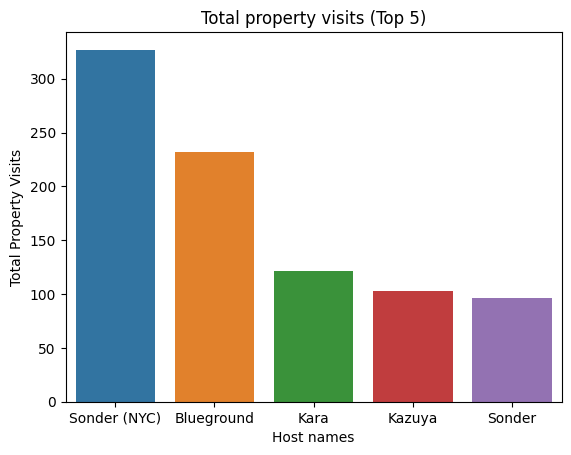

In [36]:
sns.barplot(data=popular_hosts.head(5),
            x = 'host_name', y='total_property_visits', hue='host_name')

plt.xlabel('Host names')
plt.ylabel("Total Property Visits")

plt.title("Total property visits (Top 5)")

plt.show();

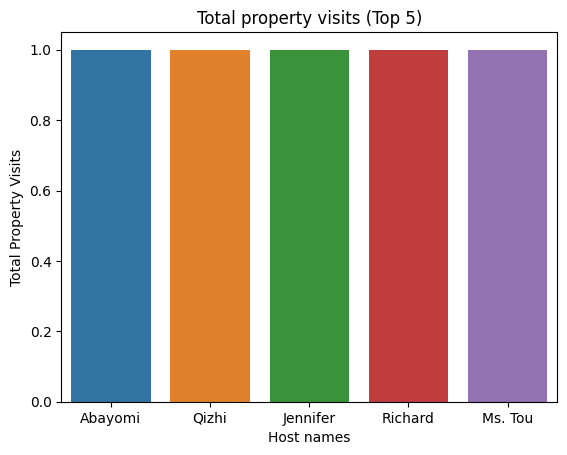

In [37]:
# least property visits
sns.barplot(data=popular_hosts.tail(5),
            x = 'host_name', y='total_property_visits', hue='host_name')

plt.xlabel('Host names')
plt.ylabel("Total Property Visits")

plt.title("Total property visits (Top 5)")

plt.show();

These top 5 hosts have their property rented out the most. Most of them are in Manhattan, Queens and Brooklyn. The reason being more tourists visit New York, the rental homes might have access to transport, the tourists can visit nearest attractions like museums, galleries etc.

In [38]:
df.sample(5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,property_category
39945,31042032,Columbia Univ Queen-bed in a Cozy Suite 5B,10415675,Yao & Rain,Manhattan,Harlem,40.82171,-73.95346,Private room,55,5,7,2019-06-01,1.09,7,154,Least Rented property
43672,33797564,SUNNY SUMMER SUBLET,73049484,Kumru,Brooklyn,Crown Heights,40.66623,-73.92874,Entire home/apt,100,50,0,NaN,0.00,2,225,Least Rented property
26810,21274330,Upper East Side 3 bed/3 bath Skyline view!,19424541,Barbara,Manhattan,Upper East Side,40.76709,-73.96422,Entire home/apt,840,4,2,2019-04-23,0.31,2,24,Least Rented property
8637,6642187,Sunny & Modern 1 Bedroom with Amazing view of NY,2536417,Anna,Manhattan,Upper East Side,40.76555,-73.95791,Entire home/apt,399,3,38,2019-07-01,0.77,1,311,Least Rented property
3084,1821541,Large 2BR apartment East Village,2208993,Chris,Manhattan,East Village,40.72210,-73.98356,Entire home/apt,420,1,53,2019-04-28,1.04,3,250,Least Rented property


In [39]:
popular_host_names = [name for name in popular_hosts['host_name'].head()]

In [40]:
popular_host_names

['Sonder (NYC)', 'Blueground', 'Kara', 'Kazuya', 'Sonder']

In [41]:
df.loc[df['host_name'].isin(popular_host_names)]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,property_category
1120,475216,Studio Apt in Park Slope- Brooklyn!,2355439,Kara,Brooklyn,Sunset Park,40.66387,-73.99077,Entire home/apt,100,2,17,2015-07-27,0.20,1,0,Least Rented property
3287,1961361,Private Master BR in 3 BR Apt,10134825,Kara,Manhattan,Lower East Side,40.71286,-73.98437,Private room,102,2,6,2016-01-02,0.13,4,0,Least Rented property
9238,7064148,Sunny room w/ Private Bath&Balcony!,11068937,Kara,Brooklyn,Greenpoint,40.73136,-73.95276,Private room,140,2,21,2016-05-30,0.43,2,0,Least Rented property
9740,7491713,NYC Lavish Studio Apartment Steps from SoHo!,30283594,Kara,Manhattan,Financial District,40.70862,-74.01408,Entire home/apt,169,30,3,2018-12-07,0.09,121,364,Least Rented property
10075,7730160,Furnished NYC 1BR apt near Rockefeller Center!!!,30283594,Kara,Manhattan,Theater District,40.75967,-73.98573,Entire home/apt,135,30,0,NaN,0.00,121,174,Least Rented property
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48723,36404684,Smart Nolita 1BR w/ W/D near famous cafes by B...,107434423,Blueground,Manhattan,Nolita,40.72283,-73.99472,Entire home/apt,316,30,0,NaN,0.00,232,325,Least Rented property
48724,36404784,Dapper Hell's Kitchen 2BR w/ Gym + W/D + Door...,107434423,Blueground,Manhattan,Hell's Kitchen,40.76082,-73.99709,Entire home/apt,385,30,0,NaN,0.00,232,338,Least Rented property
48725,36404815,Trendy Hell's Kitchen 1BR w/ Gym + W/D + Doorm...,107434423,Blueground,Manhattan,Hell's Kitchen,40.76083,-73.99727,Entire home/apt,267,30,0,NaN,0.00,232,228,Least Rented property
48726,36404936,Beautiful Williamsburg 2BR w/ Skyline views + ...,107434423,Blueground,Brooklyn,Williamsburg,40.71493,-73.96365,Entire home/apt,278,30,0,NaN,0.00,232,188,Least Rented property


In [42]:
df['avg_price'] = df.groupby(['neighbourhood_group', 'neighbourhood'])['price'].transform('mean')
df['min_price'] = df.groupby(['neighbourhood_group', 'neighbourhood'])['price'].transform('min')
df['max_price'] = df.groupby(['neighbourhood_group', 'neighbourhood'])['price'].transform('max')

In [43]:
df[['neighbourhood_group', 'neighbourhood', 'price',
    'avg_price', 'min_price', 'max_price']].sample(10)

,neighbourhood_group,neighbourhood,price,avg_price,min_price,max_price
31597,Manhattan,Theater District,165,248.013889,40,3000
10256,Manhattan,Gramercy,200,222.754438,45,3000
47832,Manhattan,Morningside Heights,250,114.783237,30,1200
39614,Bronx,Throgs Neck,99,91.041667,40,325
33625,Manhattan,Washington Heights,110,89.610679,16,1000
19385,Brooklyn,Prospect-Lefferts Gardens,70,110.401869,22,2545
33125,Bronx,Unionport,85,137.142857,60,450
31577,Manhattan,Financial District,240,225.490591,12,3000
12968,Manhattan,East Village,60,186.083108,10,3750
3932,Manhattan,Tribeca,450,490.638418,60,8500


In [44]:
df['minimum_nights'].describe()

count    48895.000000
mean         7.029962
std         20.510550
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max       1250.000000
Name: minimum_nights, dtype: float64

In [45]:
df.loc[df['minimum_nights']==1250]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,property_category,avg_price,min_price,max_price
5767,4204302,Prime W. Village location 1 bdrm,17550546,Genevieve,Manhattan,Greenwich Village,40.73293,-73.99782,Entire home/apt,180,1250,2,2014-11-09,0.03,1,365,Least Rented property,263.405612,43,6000


Again faulty entry in the dataset, with a very high entry for the minimum nights the property can be rented for.

In [46]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'property_category', 'avg_price', 'min_price',
       'max_price'],
      dtype='object')

In [47]:
# checking for correlation among a few numerical columns
columns = ['price',
       'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365']
correlation_matrix = df[columns].corr()


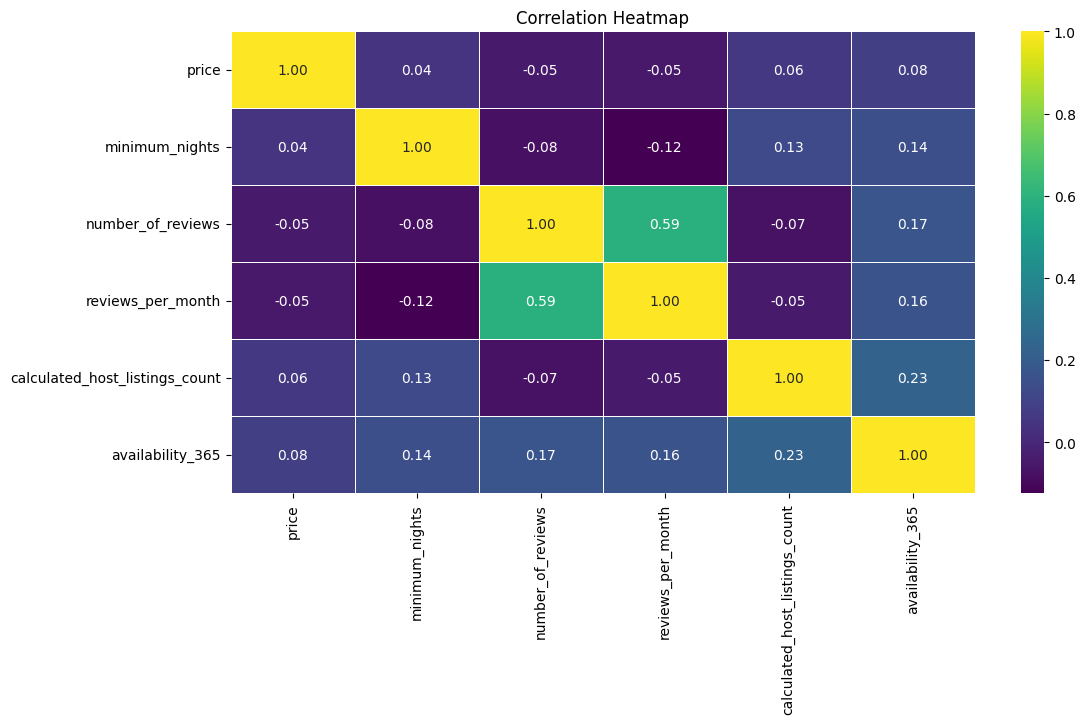

In [48]:
plt.figure(figsize=(12, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')

plt.show();

Cannot see any marked associations among these predictors at all

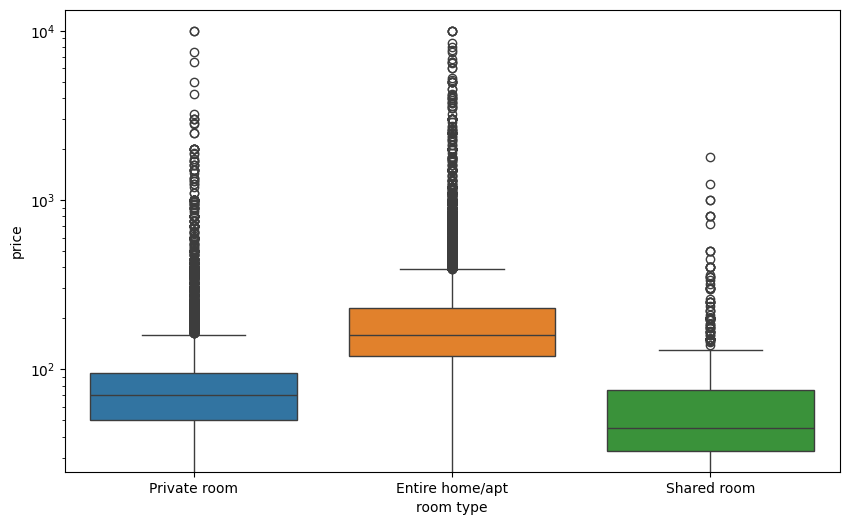

In [49]:
# checking the price comparison among different rooms using a box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='room_type', y='price', data=df, hue='room_type')
plt.yscale('log')
plt.xlabel("room type")
plt.ylabel("price")

plt.show();

There are lots of  outliers in the dataset

In [50]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'property_category', 'avg_price', 'min_price',
       'max_price'],
      dtype='object')

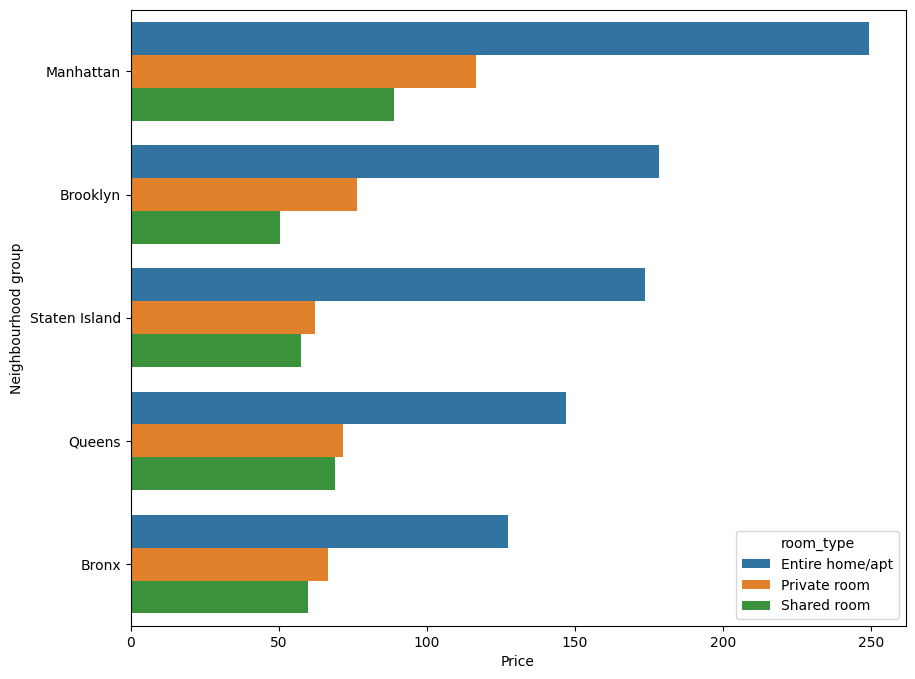

In [51]:
plt.figure(figsize=(10,  8))
sns.barplot(data=df.groupby(['neighbourhood_group', 'room_type']).agg(
    average_price=('price', 'mean' )
    )\
        .sort_values(by='average_price', ascending=False).reset_index(), 
    x = "average_price", y="neighbourhood_group", hue="room_type")


plt.xlabel("Price")
plt.ylabel("Neighbourhood group")

plt.show();